In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from pathlib import Path
from copy import copy
from skimage.filters import gaussian
import xarray as xr
from scipy.spatial.distance import euclidean, cdist

import sys


from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()


from pyS3M import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from skimage.filters import gaussian, median

from pyS3M import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from pyS3M import NileRedFunctions

NR_F = NileRedFunctions.NileRed_Functions()

In [2]:
# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../../../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 16
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), 1e-12)
camera_parameters["readnoise"] = np.full((image_size, image_size), 1e-12)
camera_parameters["rqe"] = np.full((image_size, image_size), 1.0)
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [3]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
dichroic_515_mirror = "semrock-di03-r514-t1-25x36"
nilered_filter = "semrock-ff01-650-200"
shortpass_filter = "semrock-bsp01-785r"
longpass_filter_515 = "semrock-ff01-515-lp"

filters = [nilered_filter, dichroic_515_mirror, longpass_filter_515]
filter_spectra = S_F.get_dye_or_filter_data(
    names=filters, wavelength=wavelength, dye_or_filter=False
)

In [4]:
dye = ["Nile Red"]

In [5]:
dye_spectrum = S_F.get_dye_or_filter_data(names=dye, wavelength=wavelength)
error = np.sqrt(dye_spectrum)

In [6]:
result, fitted_spectrum = S_F.spectral_fit_dye(dye_spectrum, wavelength, 
                                               model="skew-gaussian",
                                               weights=error,
                                               display=True)

In [7]:
S_F.wavelength_to_energy(result.x[1])

617.64720350096172

In [8]:
denom = np.trapz(fitted_spectrum, wavelength)
wavelength_mean = np.trapz(fitted_spectrum * wavelength, wavelength) / denom
print(wavelength_mean)

651.910539817


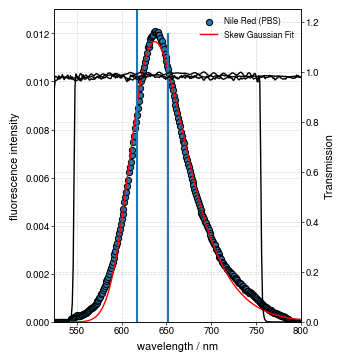

In [9]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(axs, x=wavelength, y=dye_spectrum.T, ylabel='fluorescence intensity', xlabel='wavelength / nm', 
                           label='Nile Red (PBS)', facecolor=None)
axs = plotter.line_plot(axs, x=wavelength, y=fitted_spectrum, ylabel='fluorescence intensity', xlabel='wavelength / nm', color='red',
                       label='Skew Gaussian Fit')
axs.vlines(S_F.wavelength_to_energy(result.x[1]), ymin=0, ymax=0.013)

ax2 = axs.twinx()
ax2 = plotter.line_plot(ax2, x=wavelength, y=filter_spectra.T, ylabel='Transmission')
ax2.set_ylim([0, 1.25])
axs.vlines(ymin=0, ymax=0.012, x=wavelength_mean)

axs.set_xlim([525, 800])
ax2.set_xlim([525, 800])
axs.set_ylim([0, 0.013])
axs.legend(loc='best', frameon=False, fontsize=6)
#folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
plt.show()
#plt.savefig(os.path.join(folder, 'Fit_Fluo_Spectrum.svg'), dpi=600, format='svg')

In [10]:
svalues = np.array([560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660])
len(svalues)

11

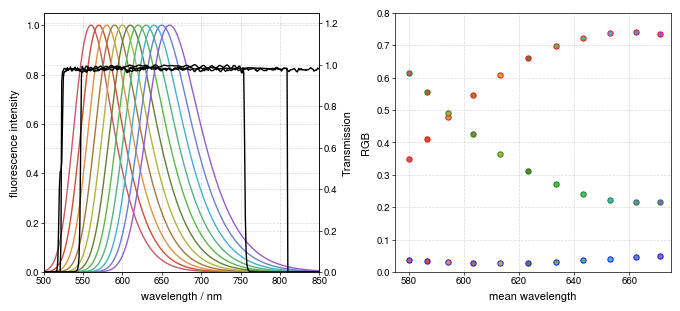

In [11]:
fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1,1])
colours = ["#c6596a",
"#ca5137",
"#e09343",
"#a2783e",
"#b3b343",
"#637f37",
"#5bb74c",
"#57b183",
"#45b0cf",
"#6c80cc",
"#935ecb",
"#c076b0",
"#cc4497"]

svalues = np.array([560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660])
for i, s in enumerate(svalues):
    # s is the desired PEAK wavelength of the rendered spectrum -- generate_nile_red_spectrum's
    # own `wavelength_center` argument is a location parameter, not the peak (the two differ
    # by tens of nm; see wavelength_center_for_peak's docstring), so convert first.
    wavelength_center = NR_F.wavelength_center_for_peak(s, wavelength)
    spectrum = NR_F.generate_nile_red_spectrum(
                wavelength_center, wavelength, normalize=True
            )
    spectrum_filtered = NR_F.apply_optical_filters(spectrum, filter_spectra)
    rgb = NR_F.calculate_rgb_from_spectrum(
            spectrum_filtered, wavelength, pixel_QYs
        )
    denom = np.trapz(spectrum_filtered, wavelength)
    wavelength_mean = np.trapz(spectrum_filtered * wavelength, wavelength) / denom

    axs[0] = plotter.line_plot(axs[0], x=wavelength, y=spectrum/np.max(spectrum), 
                               ylabel='fluorescence intensity', xlabel='wavelength / nm', color=colours[i],)

    axs[1] = plotter.scatter_plot(axs[1], x=wavelength_mean, y=rgb[0], facecolor=colours[i], xlabel='mean wavelength', edgecolor='red',
                                 ylabel='RGB', linewidth=0.6, size=15)
    axs[1] = plotter.scatter_plot(axs[1], x=wavelength_mean, y=rgb[1], facecolor=colours[i], xlabel='mean wavelength', edgecolor='green',
                                 ylabel='RGB', linewidth=0.6, size=15)
    axs[1] = plotter.scatter_plot(axs[1], x=wavelength_mean, y=rgb[2], facecolor=colours[i], xlabel='mean wavelength', edgecolor='blue',
                                 ylabel='RGB', linewidth=0.6, size=15)

axs[0].set_xlim([500, 850])
ax2 = axs[0].twinx()
ax2 = plotter.line_plot(ax2, x=wavelength, y=filter_spectra.T, ylabel='Transmission')
ax2.set_ylim([0, 1.25])
ax2.set_xlim([500, 850])

axs[0].set_ylim([0, 1.05])
axs[1].set_xlim([575, 675])
axs[1].set_ylim([0.0, 0.8])

folder = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
#plt.savefig(os.path.join(folder, 'Example_Propagation_Figure.svg'), dpi=600, format='svg')
plt.show()

In [12]:
from pyS3M import NileRedFunctions

NR_F = NileRedFunctions.NileRed_Functions()

save_folder = "/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260724_NileRedModelTesting"

# Photon range updated to match real Nile Red / NR4A exemplar data (NR/Localisations.h5,
# NR4A/Localisations.h5, and the SAureus NR4A titration): the bulk of real, QC'd
# localisations fall between ~100 and ~30,000 photons (1st-99th percentile across
# datasets), vs. the previous 500-20000 range. Lower bound set to 200 (not the raw
# ~100 floor) to match real analysis practice, which routinely excludes fits below
# 200 photons.
n_photon_space = np.logspace(np.log10(200), np.log10(10000), 25)

# Background likewise updated: real per-localisation background_photons (bg_B+bg_G+bg_R)
# medians ~35-45 for Nile Red, ~45-70 for NR4A/SAureus -- swept as three representative
# levels (previously a single, unrealistically low flat 5.0) rather than one flat value.
background_levels = [20.0, 45.0, 70.0]  # NR-like low / typical / NR4A-SAureus-like high


In [ ]:
for background_photons in background_levels:
    NR_F.simulate_wavelength_precision(
          save_folder=save_folder,
          wavelength_range=(560, 660),
          wavelength_step=5,
          photon_counts=n_photon_space,
          filter_names=filters,
          n_bootstrap=10000,
          image_size = 16,
          background_photons=background_photons,
          camera_parameters=camera_parameters,
          starting_flag=f"bg{int(background_photons)}_",
          verbose=False,
          use_tqdm=False,
      )

INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
INFO:pyS3M.IOFunctions:  Read 20,000 total localizations
INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-9999)
INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
INFO:pyS3M.IOFunctions:  Read 30,000 total localizations
INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-9999)
INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
INFO:pyS3M.IOFunctions:  Read 40,000 total localizations
INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-9999)
INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
INFO:pyS3M.IOFunctions:  Read 50,000 total localizations
INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-9999)
INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
INFO:pyS3M.IOFunctions:  Read 60,000 total localizations
INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-9999)
INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


...

INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl605_LM_method_simulated_NileRed_605nm_rawresults.h5
INFO:pyS3M.IOFunctions:  Read 180,000 total localizations
INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-9999)
INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg20_wl605_LM_method_simulated_NileRed_605nm_rawresults.h5


INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl605_LM_method_simulated_NileRed_605nm_rawresults.h5
INFO:pyS3M.IOFunctions:  Read 190,000 total localizations
INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-9999)
INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg20_wl605_LM_method_simulated_NileRed_605nm_rawresults.h5


INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl605_LM_method_simulated_NileRed_605nm_rawresults.h5
INFO:pyS3M.IOFunctions:  Read 200,000 total localizations
INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-9999)
INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg20_wl605_LM_method_simulated_NileRed_605nm_rawresults.h5


INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl605_LM_method_simulated_NileRed_605nm_rawresults.h5
INFO:pyS3M.IOFunctions:  Read 210,000 total localizations
INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-9999)
INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg20_wl605_LM_method_simulated_NileRed_605nm_rawresults.h5


INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl605_LM_method_simulated_NileRed_605nm_rawresults.h5
INFO:pyS3M.IOFunctions:  Read 220,000 total localizations
INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-9999)
INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg20_wl605_LM_method_simulated_NileRed_605nm_rawresults.h5


In [ ]:
# One summary CSV per background level (starting_flag=f"bg{int(background_photons)}_"),
# all in the same save_folder -- load and concatenate, tagging each with its background level.
# NOTE: these are the ORIGINAL summary CSVs, computed by simulate_wavelength_precision's
# own (buggy, pre-fix) Stage 2 -- kept here only for reference/comparison. The corrected
# `data` used by the plots below is computed fresh from the raw per-localisation results
# in the next cell, NOT from these CSVs.
data_frames = []
for background_photons in background_levels:
    file = f"bg{int(background_photons)}_wavelength_precision_summary.csv"
    df_bg = pd.read_csv(os.path.join(save_folder, file))
    df_bg["background_photons"] = background_photons
    data_frames.append(df_bg)
data_original = pd.concat(data_frames, ignore_index=True)

## Reprocessing the main sweep with the NaN-safe wavelength fit

`_add_nile_red_wavelength_fits` (`simulation/multicolour.py`) had a bug: its guard for
skipping a failed colour fit was `if rgb_total[j] <= 0: continue`, and `NaN <= 0` is
`False` in Python/NumPy -- so localisations whose colour fit itself failed (`A_R`/`A_G`/
`A_B` all `NaN`) were **not** skipped, and were fed straight into
`fit_nile_red_wavelength`, which doesn't detect `NaN` input either and silently returns a
spurious, deterministic "fit" (near-zero reported error) instead of failing. That fake
value got written into `wl_fit` as if it were a real per-sample estimate, and contaminated
every downstream bias/precision statistic -- worst at low photon counts, where a large
fraction of colour fits genuinely fail (measured at 55.8% of bootstraps in the bg20/560nm/
100-photon bin alone, from the original 100-photon-floor sweep -- the floor is now 200,
see below).

This is now fixed at the source, but the existing raw results in `save_folder` predate the
fix. No re-simulation is needed to correct them, though: the bug only ever affected rows
whose colour fit had already failed (`A_R` is `NaN`) -- rows with a valid colour fit went
through the normal (unaffected) code path, so their existing `wl_fit` is already correct.
Reprocessing is therefore just: drop the failed-colour-fit rows from each existing
`rawresults.h5`, then recompute `wavelength_bias`/`wavelength_precision`/`recovery_rate`
from the remaining (already-correct) `wl_fit` values -- no refitting required.

This cell defines `data` (used by every plot/analysis cell below), computed fresh from
the raw per-localisation results -- **not** from the `data_original` DataFrame loaded in
the cell just above (which reflects the original, pre-fix summary CSVs and is kept only
for reference/comparison).

In [ ]:
import re

# Reprocess every existing rawresults.h5 under save_folder: drop rows whose colour fit
# failed (NaN A_R -- these previously carried the spurious fixed-point wl_fit described
# above) and recompute the summary statistics from the remaining valid wl_fit values.
# Original (buggy) summary CSVs are left untouched on disk; corrected ones are written
# with a "_reprocessed" suffix.

# Fresh wavelength_array from setup_optical_system (not the notebook's own `wavelength`
# global), matching exactly what simulate_wavelength_precision used internally to compute
# its wl_true_com reference -- see cell 19's identical rationale for the pixellation test.
wavelength_array_reproc, _, _ = NR_F.setup_optical_system(filters)

reprocessed_records = []

# Discover which (background, true-wavelength) combinations were actually
# simulated by scanning filenames on disk directly -- self-contained, doesn't
# depend on `true_wavelengths`/`data` from any other cell.
raw_result_files = sorted(Path(save_folder).glob("bg*_wl*_*_rawresults.h5"))
name_pattern = re.compile(r"^bg(?P<bg>\d+)_wl(?P<wl>\d+)_")

files_by_bg_wl = {}
for p in raw_result_files:
    m = name_pattern.match(p.name)
    if not m:
        continue
    files_by_bg_wl.setdefault((float(m.group("bg")), float(m.group("wl"))), []).append(p)

for (background_photons, wl_true), raw_files in sorted(files_by_bg_wl.items()):

        # Same truth reference simulate_wavelength_precision's Stage 2 uses: convert the
        # true PEAK wavelength to the location parameter that actually renders a spectrum
        # peaking there, then take that location parameter's raw-spectrum centre of mass.
        wavelength_center_true = NR_F.wavelength_center_for_peak(wl_true, wavelength_array_reproc)
        wl_true_com = NR_F.spectral_centre_of_mass(wavelength_center_true, wavelength_array_reproc)

        for raw_file in raw_files:
            df_raw = IO.read_h5_database(str(raw_file))

            for level in sorted(df_raw["photon_level"].unique()):
                df_level = df_raw[df_raw["photon_level"] == level]
                n_bootstrap_level = len(df_level)

                # Drop failed colour fits (previously: spurious fixed-point wl_fit).
                df_valid = df_level[df_level["A_R"].notna()]

                wavelengths_fitted = df_valid["wl_fit"].dropna().to_numpy()
                if len(wavelengths_fitted) == 0:
                    continue

                reprocessed_records.append({
                    "wavelength_true": wl_true,
                    "background_photons": background_photons,
                    "photon_level": int(level),
                    "n_photons": df_valid["photons"].mean(),
                    "wavelength_precision": np.std(wavelengths_fitted),
                    "wavelength_bias": np.mean(wavelengths_fitted) - wl_true_com,
                    "wavelength_mean": np.mean(wavelengths_fitted),
                    "recovery_rate": len(wavelengths_fitted) / n_bootstrap_level,
                    "n_successful": len(wavelengths_fitted),
                    "n_failed_colour_fit": n_bootstrap_level - len(df_valid),
                })

data = pd.DataFrame(reprocessed_records)

for background_photons in background_levels:
    sub = data[data["background_photons"] == background_photons]
    out_path = os.path.join(save_folder, f"bg{int(background_photons)}_wavelength_precision_summary_reprocessed.csv")
    sub.drop(columns=["background_photons"]).to_csv(out_path, index=False)
    print(f"Wrote {out_path} ({len(sub)} rows)")

data

In [ ]:
true_wavelengths = np.unique(data['wavelength_true'].to_numpy())

In [ ]:
data['wavelength_true']

In [ ]:
import matplotlib.colors as mcolors

folder = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
fs = plotter.config.font_size

# Surface plots (matching Figure1_SBR.ipynb's style): rows = metric (one figure each),
# cols = background level. x = N_photons (log, aligned to n_photon_space via
# photon_level's index -- the fitted mean `n_photons` varies slightly by wavelength at
# the same nominal level, so it isn't a clean shared grid coordinate), y = true
# wavelength, colour = the metric.
metric_info = [
    ('wavelength_precision', 'spectral estimation σ/nm', 'viridis'),
    ('wavelength_bias', 'spectral bias/nm', 'RdBu_r'),
]

n_levels = len(n_photon_space)

for metric, cbar_lbl, cmap in metric_info:
    # Build a (background, wavelength, photon_level) grid for this metric.
    Z_all = np.full((len(background_levels), len(true_wavelengths), n_levels), np.nan)
    for i_bg, bg in enumerate(background_levels):
        data_bg = data[data['background_photons'] == bg]
        for i_wl, wl in enumerate(true_wavelengths):
            sub = data_bg[data_bg['wavelength_true'] == wl]
            for _, row in sub.iterrows():
                Z_all[i_bg, i_wl, int(row['photon_level'])] = row[metric]

    if metric == 'wavelength_bias':
        # Diverging, centred on zero -- bias can be positive or negative.
        vmax = float(np.nanpercentile(np.abs(Z_all), 99))
        norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)
    else:
        vmin = float(np.nanmin(Z_all))
        vmax = float(np.nanpercentile(Z_all, 99))
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig, axs = plt.subplots(
        nrows=1, ncols=len(background_levels), figsize=(6.69, 2.4), squeeze=False,
    )
    for i_bg, bg in enumerate(background_levels):
        ax = axs[0, i_bg]
        Z = Z_all[i_bg]  # (n_wavelength, n_photon_levels)
        # rasterized=True embeds the mesh as a bitmap in the saved SVG instead of
        # per-quad vector polygons -- avoids thin gray/white seams between adjacent
        # pcolormesh cells on vector export (see Figure1_SBR.ipynb's identical note).
        ax.pcolormesh(
            n_photon_space, true_wavelengths, Z,
            cmap=cmap, shading='auto', norm=norm, rasterized=True,
        )
        ax.set_xscale('log')
        ax.set_xlabel(r'$N_{\rm photons}$', fontsize=fs + 1)
        ax.set_ylabel('true nile red wavelength/nm' if i_bg == 0 else '', fontsize=fs + 1)
        ax.set_title(f'background = {int(bg)} photons/pixel', fontsize=fs)
        ax.tick_params(labelsize=fs - 1)

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=axs, label=cbar_lbl, shrink=0.85, aspect=20, pad=0.02,
    )
    fname = f'Forward_Model_Validation_surface_{metric}.svg'
    plotter.save_or_show(fig, save_path=os.path.join(folder, fname), show=True, dpi=600)
    print(f'Saved {fname}')

## Does pixellating localisations before fitting reduce bias?

Real Nile Red/NR4A analysis (`NileRedFunctions.fit_wavelengths_pixelated`) spatially bins
many localisations and fits one wavelength per bin, rather than fitting every
localisation individually -- on the assumption that pooling improves things. That
assumption has never been checked against known ground truth. Here we simulate
`N_BOOTSTRAP_PT` independent localisations at a single known true wavelength, photon
level and background, then compare three ways of turning them into a wavelength
estimate:

- **(a) Individual** (`k=1`) -- fit each localisation's own wavelength independently
  (the existing per-bootstrap `wl_fit`, unbinned) -- current production behaviour.
- **(b) Pixellated/pooled** (`k>1`) -- group localisations into batches of `k` and combine
  each group the same way the real pipeline combines localisations for pixellated data
  (`NileRedFunctions.fit_wavelengths_pixelated`'s per-pixel binning): an inverse-error-
  weighted average of each localisation's own already-fitted `A_R`/`A_G`/`A_B`/`s_x`/`s_y`
  (`_weighted_average_with_error`), RGB-renormalised with error propagation
  (`_normalize_rgb_with_errors`), then fit **once** per group. (An earlier version of this
  test instead reconstructed and summed raw amplitude-times-photons counts across the
  group -- a different operation that isn't what the real pipeline does, and that let
  each low-photon localisation's own colour-fit bias carry through into the pooled
  estimate with equal weight regardless of its individual precision.)
- **(c) Equal-photon-budget control** -- a separate simulation at
  `n_photon = k * photon_level`, i.e. the same total photon budget as (b) achieved in one
  shot rather than pooled -- checked as a sanity check on the grouping code, and to see
  whether pooling many dim localisations is as good as one bright one.

`photon_level` sweeps `PHOTON_LEVELS_PT` (representative per-localisation photon counts
from the updated real-data range above); `k` sweeps `K_VALUES_PT` (realistic render-pixel
occupancy, matching the "~25 locs/pixel" figure already used for the real 50 nm
pixellated fit). Background is fixed at a representative `BACKGROUND_PT` and true
wavelength at `WL_TRUE_PT` to keep this exploratory grid a manageable size -- the sweep
above already covers the full wavelength/background range for the unbinned baseline.

In [ ]:
# Fresh wavelength_array/pixel_QYs/filter_spectra from setup_optical_system, rather than
# reusing the notebook's `wavelength` global -- the validation-figure cell above runs
# `for wavelength in true_wavelengths:`, which overwrites `wavelength` (originally the
# spectral wavelength grid) with a scalar. Distinct names here avoid that collision.
wavelength_array, pixel_QYs_pt, filter_spectra_pt = NR_F.setup_optical_system(filters)

pixel_pt_size = 69.0  # nm
NA_pt = 1.49
WL_TRUE_PT = 600.0     # representative true PEAK wavelength for this test
BACKGROUND_PT = 45.0   # representative background (median across real NR/NR4A datasets)
# N_BOOTSTRAP_PT increased from 3000 -> 20000: reaching photon_level_max * k = 2e7
# needs k=2000 (since PHOTON_LEVELS_PT tops out at 10000/localisation), and
# fit_pixelated_groups needs N_BOOTSTRAP_PT // k independent groups to pool. (1e8 was
# tried first -- it needs k=10000, which would need N_BOOTSTRAP_PT>=50000 for even a
# thin 5 groups at that k, a 16.7x cost increase; dialed back to 2e7/k=2000, which
# only needs this more modest 6.7x increase for a healthier 10 groups at the top end.)
N_BOOTSTRAP_PT = 20000
PHOTON_LEVELS_PT = np.array([200.0, 300.0, 1000.0, 3000.0, 10000.0])  # per-localisation
# Extended to reach photon_level_max * k = 2e7 (10000 * 2000), spanning the full
# measured real-data range of ~1e4-1e7 photons/pixel with margin either side.
K_VALUES_PT = [1, 5, 10, 25, 50, 100, 250, 500, 1000, 2000]

pixellation_save_folder = "/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260724_NileRed_PixellationTest"
os.makedirs(pixellation_save_folder, exist_ok=True)

# WL_TRUE_PT is the desired PEAK wavelength, not generate_nile_red_spectrum's own
# location-parameter argument (the two differ by tens of nm -- see
# wavelength_center_for_peak's docstring) -- convert before generating, so
# spectrum_pt (what get_localisation_batch actually simulates images from) really
# peaks at WL_TRUE_PT.
WAVELENGTH_CENTER_PT = NR_F.wavelength_center_for_peak(WL_TRUE_PT, wavelength_array)
spectrum_pt = NR_F.generate_nile_red_spectrum(WAVELENGTH_CENTER_PT, wavelength_array, normalize=True)

# fit_nile_red_wavelength returns the raw (un-filtered) spectrum's centre of mass,
# evaluated at whatever location parameter the LSQ fit recovers -- compare bias
# against that *same* quantity computed at the true location parameter
# (WAVELENGTH_CENTER_PT), not against WL_TRUE_PT directly (which would reintroduce
# the ~20 nm peak-vs-mean gap as spurious bias) and not against
# spectral_centre_of_mass(WL_TRUE_PT, ...) either (WL_TRUE_PT is a peak, not a
# location parameter, so that would be a different, additional error again).
WL_TRUE_COM_PT = NR_F.spectral_centre_of_mass(WAVELENGTH_CENTER_PT, wavelength_array)
print(f"WL_TRUE_PT (peak) = {WL_TRUE_PT:.2f} nm; "
      f"location parameter = {WAVELENGTH_CENTER_PT:.2f} nm; "
      f"true spectral centre of mass = {WL_TRUE_COM_PT:.2f} nm")

In [ ]:
def get_localisation_batch(photon_level, flag_suffix):
    """Simulate N_BOOTSTRAP_PT independent localisations at WL_TRUE_PT/BACKGROUND_PT/
    photon_level (via the same test_fit_method/_add_nile_red_wavelength_fits machinery
    the main sweep above uses), returning the raw per-localisation fit DataFrame
    (A_R/A_G/A_B/s_x/s_y/photons/background_photons + individual wl_fit)."""
    config = Multicolour_Simulation_Functions.SimulationConfig(
        n_bootstrap=N_BOOTSTRAP_PT,
        background_photons=BACKGROUND_PT,
        NA=NA_pt,
        pixel_size=pixel_pt_size,
        cpu_fraction=0.9,
        save_raw_results=True,
        subtractx0y0=False,
        saverawimages=False,
    )
    flag = f"pixtest_{flag_suffix}_"
    dyestr = f"simulated_NileRed_{int(WL_TRUE_PT)}nm"

    MSF.test_fit_method(
        dye=dyestr,
        filters=filters,
        wavelength=wavelength_array,
        camera_parameters=camera_parameters,
        save_folder=pixellation_save_folder,
        n_photon_space=np.array([photon_level]),
        smoothing_function=smoothing_function,
        starting_flag=flag,
        config=config,
        single_dye_spectrum=spectrum_pt,
        nile_red_wavelength=WL_TRUE_PT,
    )

    raw_files = list(Path(pixellation_save_folder).glob(f"{flag}*rawresults.h5"))
    return IO.read_h5_database(str(raw_files[0]))

In [ ]:
def combine_group(df_group):
    """Combine a group of independent localisations into one pixel-level observation
    using the SAME method the real pipeline uses for pixellated data
    (NileRedFunctions.fit_wavelengths_pixelated's per-pixel binning): an inverse-error-
    weighted average of each localisation's own already-fitted A_R/A_G/A_B/s_x/s_y
    (NR_F._weighted_average_with_error, weights = 1/error), then RGB-renormalise with
    error propagation (NR_F._normalize_rgb_with_errors) -- not a sum of amplitude-times-
    photons reconstructed raw counts (a different operation, and not what the real code
    does). photons/background_photons are still summed across the group, but only for
    the SNR-based error-inflation term inside fit_nile_red_wavelength, not to rebuild
    amplitudes."""
    avg_R, avg_R_err = NR_F._weighted_average_with_error(
        df_group['A_R'].to_numpy(), df_group['A_R_err'].to_numpy())
    avg_G, avg_G_err = NR_F._weighted_average_with_error(
        df_group['A_G'].to_numpy(), df_group['A_G_err'].to_numpy())
    avg_B, avg_B_err = NR_F._weighted_average_with_error(
        df_group['A_B'].to_numpy(), df_group['A_B_err'].to_numpy())
    avg_sx, avg_sx_err = NR_F._weighted_average_with_error(
        df_group['s_x'].to_numpy(), df_group['s_x_err'].to_numpy())
    avg_sy, avg_sy_err = NR_F._weighted_average_with_error(
        df_group['s_y'].to_numpy(), df_group['s_y_err'].to_numpy())

    sigma_x_group = avg_sx * pixel_pt_size
    sigma_y_group = avg_sy * pixel_pt_size
    sigma_x_err_group = avg_sx_err * pixel_pt_size
    sigma_y_err_group = avg_sy_err * pixel_pt_size

    rgb = np.array([avg_R, avg_G, avg_B])
    rgb_err = np.array([avg_R_err, avg_G_err, avg_B_err])
    rgb_norm, rgb_norm_err = NR_F._normalize_rgb_with_errors(rgb, rgb_err)

    total_photons = float(df_group['photons'].to_numpy().sum())
    background_photons_group = float(df_group['background_photons'].to_numpy().sum())

    return (
        rgb_norm, rgb_norm_err, sigma_x_group, sigma_y_group,
        sigma_x_err_group, sigma_y_err_group, total_photons, background_photons_group,
    )

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

def fit_pixelated_groups(df, k, shuffle=False):
    """Split df into non-overlapping groups of size k, combine each group via
    combine_group (matching the real per-pixel binning method), and fit one wavelength
    per group. shuffle=True randomises row order first -- needed when df is a pool of
    several concatenated photon levels, so each group is a genuine random mix rather
    than (near-)homogeneous consecutive blocks from the concatenation order.

    Returns (wl_pixel, total_photons_pixel): both length n_groups, NaN where a group's
    combine/fit failed or was skipped."""
    if shuffle:
        df = df.sample(frac=1.0).reset_index(drop=True)
    n_groups = len(df) // k
    df_trim = df.iloc[: n_groups * k]
    wl_pixel = np.full(n_groups, np.nan)
    total_photons_pixel = np.full(n_groups, np.nan)

    for g in range(n_groups):
        group = df_trim.iloc[g * k: (g + 1) * k]
        try:
            rgb_norm, rgb_norm_err, sx, sy, sx_err, sy_err, tot_photons, tot_bg = combine_group(group)
        except (ZeroDivisionError, ValueError):
            continue
        # NaN <= 0 is False, so a plain `<= 0` check silently lets a NaN-contaminated
        # group average (from a failed individual colour fit pooled into this group)
        # through into fit_nile_red_wavelength, which doesn't detect NaN input either
        # and returns a spurious, deterministic "fit" (near-zero reported error) instead
        # of failing. Explicitly require finite as well as positive.
        if not np.all(np.isfinite(rgb_norm)) or np.any(rgb_norm <= 0):
            continue
        wl, _ = NR_F.fit_nile_red_wavelength(
            observed_rgb=rgb_norm, observed_sigma_x=sx, observed_sigma_y=sy,
            rgb_errors=rgb_norm_err, sigma_x_error=sx_err, sigma_y_error=sy_err,
            filter_spectra=filter_spectra_pt, wavelength_array=wavelength_array,
            pixel_QYs=pixel_QYs_pt, NA=NA_pt, total_photons=tot_photons,
            background_photons=tot_bg,
        )
        wl_pixel[g] = wl
        total_photons_pixel[g] = tot_photons

    return wl_pixel, total_photons_pixel

In [ ]:
results_records = []

for photon_level in PHOTON_LEVELS_PT:
    df = get_localisation_batch(photon_level, flag_suffix=f"p{int(photon_level)}")

    # Drop localisations whose colour fit failed (NaN A_R/A_G/A_B) before doing
    # anything else -- these would never reach wavelength-fitting in the real
    # analysis pipeline (_add_nile_red_wavelength_fits skips them, now NaN-safe).
    # Previously these survived here with a fixed-point wl_fit value (the NaN
    # input silently produces a spurious, deterministic "fit" rather than NaN),
    # which corrupted both the individual (k=1) stats and the pooled photon sums
    # -- explaining the ~1e-13 "precision" once enough groups became NaN-dominated.
    n_before = len(df)
    df = df[df['A_R'].notna()].reset_index(drop=True)
    print(f"photon_level={photon_level}: dropped {n_before - len(df)}/{n_before} failed colour fits before fitting")

    for k in K_VALUES_PT:
        if k == 1:
            # (a) individual fits -- already computed per-localisation by
            # _add_nile_red_wavelength_fits inside test_fit_method, no pooling.
            wl_values = df['wl_fit'].to_numpy()
        else:
            # (b) pixellated/pooled fits.
            wl_values, _ = fit_pixelated_groups(df, k)
        wl_values = wl_values[~np.isnan(wl_values)]
        if len(wl_values) == 0:
            continue
        results_records.append({
            'photon_level': photon_level,
            'k': k,
            'bias': np.mean(wl_values) - WL_TRUE_COM_PT,
            'precision': np.std(wl_values),
            'n_groups': len(wl_values),
        })

pixellation_results = pd.DataFrame(results_records)
pixellation_results.to_csv(os.path.join(pixellation_save_folder, 'pixellation_bias_precision.csv'), index=False)
pixellation_results

In [ ]:
# Sanity check (c): equal-photon-budget control. Fits n_photon = k*photon_level in one
# shot (no pooling) at a fixed check k (below), for the smallest and largest per-localisation
# photon levels -- should roughly match the pixellated (b) bias/precision at the same
# (photon_level, k), confirming the grouping/summing code above isn't silently wrong.
control_records = []
# Deliberately NOT K_VALUES_PT[-1] (now 2000): this control's cost is one
# get_localisation_batch call per photon_level at n_photon = photon_level * k_check,
# so following K_VALUES_PT's max here would mean simulating N_BOOTSTRAP_PT
# localisations at up to photon_level_max * 2000 = 2e7 photons each, purely as a
# sanity check. k_check=50 (the original ceiling before this section's k-range was
# extended) already validates the grouping/summing code without that blow-up.
k_check = 50
for photon_level in [PHOTON_LEVELS_PT[0], PHOTON_LEVELS_PT[-1]]:
    df_control = get_localisation_batch(photon_level * k_check, flag_suffix=f"control_p{int(photon_level)}_k{k_check}")
    wl_control = df_control['wl_fit'].to_numpy()
    wl_control = wl_control[~np.isnan(wl_control)]
    control_records.append({
        'photon_level': photon_level, 'k': k_check,
        'equivalent_total_photons': photon_level * k_check,
        'bias': np.mean(wl_control) - WL_TRUE_COM_PT,
        'precision': np.std(wl_control),
    })

control_df = pd.DataFrame(control_records)
print("Equal-photon-budget control (c):")
print(control_df)
print("\nPixellated (b) at the same (photon_level, k) for comparison:")
print(pixellation_results[
    (pixellation_results['k'] == k_check)
    & (pixellation_results['photon_level'].isin([PHOTON_LEVELS_PT[0], PHOTON_LEVELS_PT[-1]]))
])

In [ ]:
fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1, 1])

# Generated (not hardcoded) so this always covers K_VALUES_PT regardless of length --
# it previously only had entries for the original 5 k values.
k_colours = dict(zip(K_VALUES_PT, plt.cm.viridis(np.linspace(0, 1, len(K_VALUES_PT)))))

# Real pixellated render data accumulates ~1e4-1e7 photons per render pixel -- plot
# against that (photon_level * k, the total pooled budget landing in one pixel) rather
# than photons per individual localisation, and highlight that measured range.
REAL_PHOTONS_PER_PIXEL_RANGE = (1e4, 1e7)

for k in K_VALUES_PT:
    subset = pixellation_results[pixellation_results['k'] == k].sort_values('photon_level')
    if len(subset) == 0:
        continue
    photons_per_pixel = subset['photon_level'] * k
    axs[0] = plotter.line_plot(
        axs[0], photons_per_pixel, subset['precision'],
        label=f'k={k}', color=k_colours[k],
        xlabel=r'$N_{\rm photons}$ per pixel',
        ylabel='wavelength precision (σ) / nm',
    )
    axs[1] = plotter.line_plot(
        axs[1], photons_per_pixel, subset['bias'],
        label=f'k={k}', color=k_colours[k],
        xlabel=r'$N_{\rm photons}$ per pixel',
        ylabel='wavelength bias / nm',
    )

for i, ax in enumerate(axs):
    ax.axvspan(
        *REAL_PHOTONS_PER_PIXEL_RANGE, color='0.5', alpha=0.15, zorder=0,
        label='measured range (real data)' if i == 1 else None,
    )

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].axhline(0.0, color='k', lw=0.6, ls='--')
axs[1].legend(loc='best', fontsize=6)

fig.suptitle(
    f'Pixellation test: true wavelength={WL_TRUE_PT:.0f} nm, background={BACKGROUND_PT:.0f} photons/pixel',
    fontsize=8,
)

folder_pt = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
plt.savefig(os.path.join(folder_pt, 'Pixellation_Bias_Precision.svg'), dpi=600, format='svg')
plt.show()

## Precision/bias surfaces across wavelength and total post-pixellation photons

The pixellation test above is at a single representative wavelength (`WL_TRUE_PT`).
Here we extend it to a genuine surface -- true wavelength on one axis, total
photons landing in a render pixel after pixellation on the other -- reusing all
21 `true_wavelengths` from the main sweep.

Real pixellated data does not accumulate a homogeneous set of same-brightness
localisations into a pixel -- molecules of very different native photon counts land in
the same render pixel together. So rather than stratifying by a single nominal
`photon_level` and picking one `(photon_level, k)` combination per total, this pools the
localisations from **all** `PHOTON_LEVELS_PT` together first, then for each group size
`k` in `K_VALUES_SURFACE` shuffles that pooled set and chunks it into non-overlapping
groups of `k` -- so every group is a genuine random mix across photon levels, and its
resulting total photon count varies group-to-group rather than being a fixed
`photon_level * k`. Combining every group's `(total_photons, wl_fit)` outcome (across
every `k`, plus the unpooled individual `k=1` fits) gives many different realisations
landing at similar total photons via different routes -- exactly what real pixel binning
does. These are then binned by their own achieved total photons into
`N_TOTAL_PHOTON_BINS` (~50) log-spaced bins, and the **mean** bias/precision is taken
within each bin -- a natural Monte Carlo estimate of the real, heterogeneous mixture,
rather than a conservative worst-case picked from an artificial grid (the previous
approach here).

In [ ]:
# PHOTON_LEVELS_PT stays as-is (5 values) -- each one requires its own expensive
# get_localisation_batch simulation. K is cheap to make dense (pooling into different
# k's from the SAME already-simulated per-localisation dataframe needs no extra
# simulation), so K_VALUES_SURFACE is much denser than K_VALUES_PT above, chosen so
# photon_level * k densely (and redundantly/overlappingly) populates the bins below.
K_VALUES_SURFACE = [1, 2, 3, 4, 5, 6, 8, 11, 14, 18, 23, 30, 39, 51, 66, 86, 112, 145,
                    189, 246, 319, 415, 539, 701, 911, 1184, 1539, 2000]

N_TOTAL_PHOTON_BINS = 50
TOTAL_PHOTON_BIN_EDGES = np.logspace(
    np.log10(PHOTON_LEVELS_PT.min() * min(K_VALUES_SURFACE)),
    np.log10(PHOTON_LEVELS_PT.max() * max(K_VALUES_SURFACE)),
    N_TOTAL_PHOTON_BINS + 1,
)
TOTAL_PHOTON_BIN_CENTERS = np.sqrt(TOTAL_PHOTON_BIN_EDGES[:-1] * TOTAL_PHOTON_BIN_EDGES[1:])

print(f"Total-photons-per-pixel bins: {TOTAL_PHOTON_BIN_EDGES[0]:.0f} - "
      f"{TOTAL_PHOTON_BIN_EDGES[-1]:.0f}, {N_TOTAL_PHOTON_BINS} bins")


def get_localisation_batch_multi_wl(photon_level, wl_true, flag_suffix):
    """Like get_localisation_batch above, but parameterised by true wavelength instead
    of the fixed WL_TRUE_PT -- generates the spectrum fresh for each wl_true (same
    peak -> location-parameter conversion simulate_wavelength_precision's Stage 1
    uses), rather than reusing the single global spectrum_pt."""
    wavelength_center = NR_F.wavelength_center_for_peak(wl_true, wavelength_array)
    spectrum = NR_F.generate_nile_red_spectrum(wavelength_center, wavelength_array, normalize=True)

    config = Multicolour_Simulation_Functions.SimulationConfig(
        n_bootstrap=N_BOOTSTRAP_PT,
        background_photons=BACKGROUND_PT,
        NA=NA_pt,
        pixel_size=pixel_pt_size,
        cpu_fraction=0.9,
        save_raw_results=True,
        subtractx0y0=False,
        saverawimages=False,
    )
    flag = f"pixtest_surf_wl{int(wl_true)}_{flag_suffix}_"
    dyestr = f"simulated_NileRed_{int(wl_true)}nm"

    MSF.test_fit_method(
        dye=dyestr,
        filters=filters,
        wavelength=wavelength_array,
        camera_parameters=camera_parameters,
        save_folder=pixellation_save_folder,
        n_photon_space=np.array([photon_level]),
        smoothing_function=smoothing_function,
        starting_flag=flag,
        config=config,
        single_dye_spectrum=spectrum,
        nile_red_wavelength=wl_true,
    )

    raw_files = list(Path(pixellation_save_folder).glob(f"{flag}*rawresults.h5"))
    return IO.read_h5_database(str(raw_files[0]))

In [ ]:
surface_precision = np.full((len(true_wavelengths), N_TOTAL_PHOTON_BINS), np.nan)
surface_bias = np.full((len(true_wavelengths), N_TOTAL_PHOTON_BINS), np.nan)
surface_n = np.zeros((len(true_wavelengths), N_TOTAL_PHOTON_BINS), dtype=int)
folder_pt = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'

for i_wl, wl_true in enumerate(true_wavelengths):
    wavelength_center_wl = NR_F.wavelength_center_for_peak(wl_true, wavelength_array)
    wl_true_com = NR_F.spectral_centre_of_mass(wavelength_center_wl, wavelength_array)

    # Pool localisations across ALL PHOTON_LEVELS_PT -- real pixellated data mixes
    # molecules of very different native brightness landing in the same render pixel,
    # not a homogeneous set drawn from one nominal photon level.
    level_dfs = []
    for photon_level in PHOTON_LEVELS_PT:
        df_level = get_localisation_batch_multi_wl(
            photon_level, wl_true, flag_suffix=f"p{int(photon_level)}"
        )
        # Drop failed colour fits before pooling (same reasoning as the main
        # pixellation loop above).
        level_dfs.append(df_level[df_level['A_R'].notna()])
    df_pool = pd.concat(level_dfs, ignore_index=True)

    # k=1: every individual localisation in the pool, already fit individually --
    # naturally mixes all photon levels (real single-localisation pixels).
    total_photons_all = [df_pool['photons'].to_numpy()]
    wl_fit_all = [df_pool['wl_fit'].to_numpy()]

    # k>1: shuffle the pooled set and chunk into non-overlapping groups of size k, so
    # each group is a random MIX of localisations from across all photon levels (not a
    # stratified single-level batch) -- reshuffling per k (inside fit_pixelated_groups)
    # draws a fresh random combination each time, giving many different
    # (total_photons, wl_fit) outcomes per k rather than one engineered value.
    for k in K_VALUES_SURFACE:
        if k == 1:
            continue
        wl_values, photons_values = fit_pixelated_groups(df_pool, k, shuffle=True)
        total_photons_all.append(photons_values)
        wl_fit_all.append(wl_values)

    total_photons_all = np.concatenate(total_photons_all)
    wl_fit_all = np.concatenate(wl_fit_all)
    valid = np.isfinite(total_photons_all) & np.isfinite(wl_fit_all)
    total_photons_all = total_photons_all[valid]
    wl_fit_all = wl_fit_all[valid]

    # Bin every realisation by its OWN resulting total photons and take the mean --
    # the natural Monte Carlo estimate of what real pixellated data would show at that
    # photon-per-pixel level (many different photon_level/k combinations land in the
    # same bin; averaging them reflects the real, heterogeneous mixture, rather than
    # picking a single conservative worst case from an engineered grid).
    bin_idx = np.searchsorted(TOTAL_PHOTON_BIN_EDGES, total_photons_all, side='right') - 1
    for b in range(N_TOTAL_PHOTON_BINS):
        in_bin = wl_fit_all[bin_idx == b]
        if len(in_bin) == 0:
            continue
        surface_bias[i_wl, b] = np.mean(in_bin) - wl_true_com
        surface_precision[i_wl, b] = np.std(in_bin)
        surface_n[i_wl, b] = len(in_bin)

    print(f"wavelength_true={wl_true:.0f} nm done "
          f"({np.sum(~np.isnan(surface_bias[i_wl]))}/{N_TOTAL_PHOTON_BINS} bins populated, "
          f"{len(wl_fit_all)} total realisations)")

np.save(os.path.join(pixellation_save_folder, 'surface_precision.npy'), surface_precision)
np.save(os.path.join(pixellation_save_folder, 'surface_bias.npy'), surface_bias)
np.save(os.path.join(pixellation_save_folder, 'surface_n.npy'), surface_n)

In [ ]:
import matplotlib.colors as mcolors

fs = plotter.config.font_size
folder_pt = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'

# Real pixellated render data accumulates ~1e4-1e7 photons per render pixel.
REAL_PHOTONS_PER_PIXEL_RANGE = (1e4, 1e7)


min_photon = 1000
photons_to_plot_index = np.argmin(np.abs(TOTAL_PHOTON_BIN_CENTERS - min_photon))
photons_to_plot = TOTAL_PHOTON_BIN_CENTERS[photons_to_plot_index:]
surface_precision_toplot = surface_precision[:, photons_to_plot_index:]
surface_bias_toplot = surface_bias[:, photons_to_plot_index:]

metric_arrays = [
    ('precision', surface_precision_toplot, 'spectral estimation σ / nm', 'viridis'),
    ('bias', surface_bias_toplot, 'spectral bias / nm', 'RdBu_r'),
]


for name, Z, cbar_lbl, cmap in metric_arrays:
    if name == 'bias':
        # Diverging, centred on zero -- bias can be positive or negative.
        vmax = float(np.nanpercentile(np.abs(Z), 99))
        norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)
    else:
        vmin = float(np.nanmin(Z))
        vmax = float(np.nanpercentile(Z, 99))
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(3.5, 2.6))
    # rasterized=True embeds the mesh as a bitmap in the saved SVG instead of per-quad
    # vector polygons -- avoids thin gray/white seams between adjacent pcolormesh cells
    # on vector export (see Figure1_SBR.ipynb's identical note).
    ax.pcolormesh(
        photons_to_plot, true_wavelengths, Z,
        cmap=cmap, shading='auto', norm=norm, rasterized=True,
    )
    ax.set_xscale('log')
    ax.set_xlabel(r'$N_{\rm photons}$ per pixel (post-pixellation)', fontsize=fs + 1)
    ax.set_ylabel('true nile red wavelength / nm', fontsize=fs + 1)
    ax.tick_params(labelsize=fs - 1)

    # Mark the measured real-data range without obscuring the colour surface
    # underneath (a shaded axvspan would muddy the colours; dashed lines don't).
    if name == 'precision':
        color = 'white'
    else:
        color = 'k'
    for x in REAL_PHOTONS_PER_PIXEL_RANGE:
        ax.axvline(x, color=color, lw=0.8, ls='--')

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax, label=cbar_lbl, shrink=0.85, pad=0.03,
    )
    fname = f'Pixellation_surface_{name}.svg'
    plotter.save_or_show(fig, save_path=os.path.join(folder_pt, fname), show=True, dpi=600)
    print(f'Saved {fname}')

In [ ]:
np.argmin(np.abs(TOTAL_PHOTON_BIN_CENTERS - 1000))

In [ ]:
TOTAL_PHOTON_BIN_CENTERS[9:]